### Import the necessary Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

### Load the datas set

In [33]:
wine_df = pd.read_csv('winequality-red.csv')
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Getting statistical Summary of data set

In [34]:
wine_df.shape

(1599, 12)

In [35]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


There are no missing vales in the dataset

In [36]:
wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [37]:
wine_df.shape

(1599, 12)

### Data Analysis and Visualization

#### i. Number of values for each quality

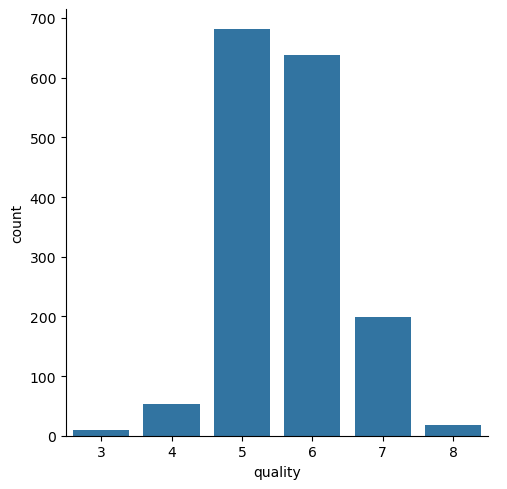

In [38]:
sns.catplot(x='quality', data = wine_df, kind = 'count')

#### ii. Column correlation:

<Axes: xlabel='quality', ylabel='volatile acidity'>

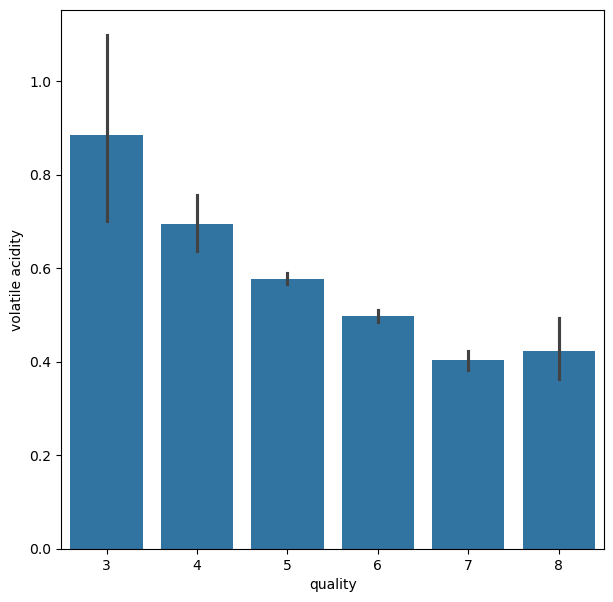

In [39]:
# volatile acidity vs quality
plt.figure(figsize = (7, 7))
sns.barplot(data = wine_df, x = 'quality', y = 'volatile acidity')

From the bar chart, it can be seen that the higher the volatile acidity the lower the quality of the wine. 

<Axes: xlabel='quality', ylabel='citric acid'>

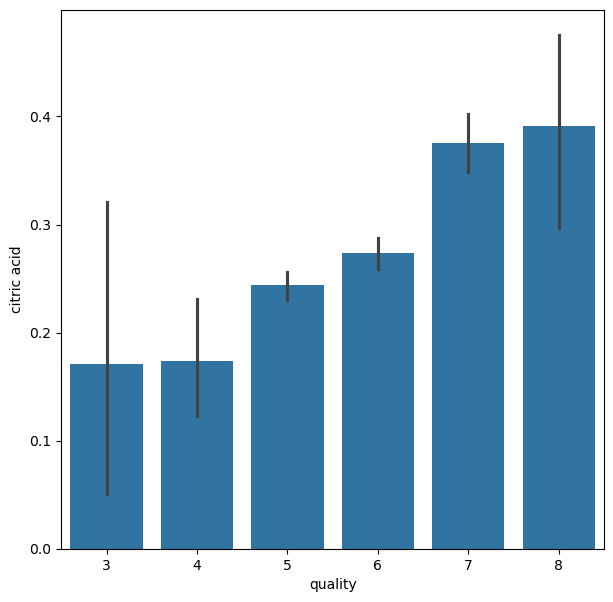

In [40]:
# citric acid vs quality
plt.figure(figsize = (7, 7))
sns.barplot(data = wine_df, x = 'quality', y = 'citric acid')

From the above bar chart, the higher the cirtric acid, the higher the quality of the wine. These two columns are directly proportional to each other.

In [41]:
# Correlation of all the columns with quality
corr = wine_df.corr().sort_values(by='quality', ascending = False)
corr

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
quality,0.124052,-0.390558,0.226373,0.013732,-0.128907,-0.050656,-0.185100,-0.174919,-0.057731,0.251397,0.476166,1.000000
alcohol,-0.061668,-0.202288,0.109903,0.042075,-0.221141,-0.069408,-0.205654,-0.496180,0.205633,0.093595,1.000000,0.476166
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919


<Axes: >

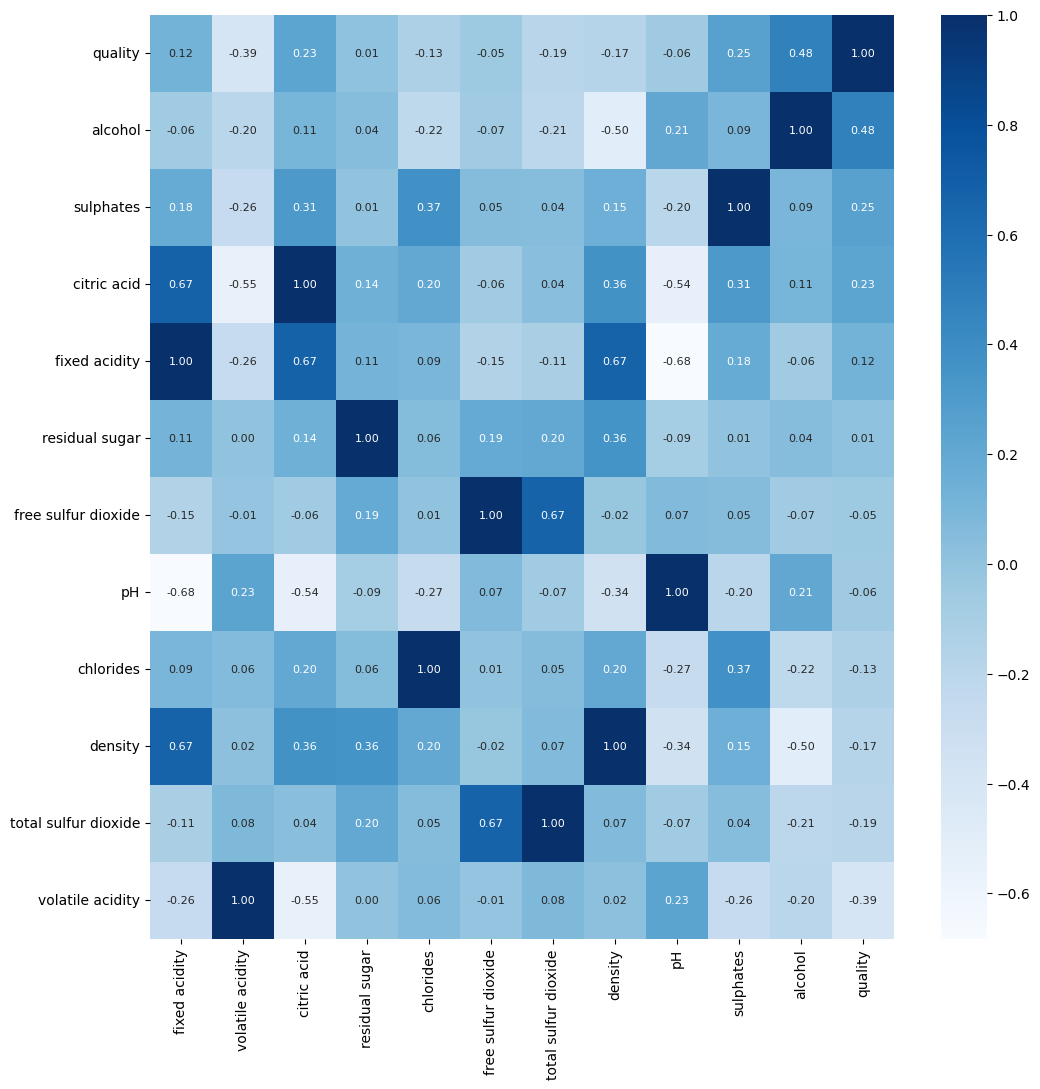

In [42]:
# Plotting the correlation in a heatmap
plt.figure(figsize = (12, 12))

sns.heatmap(corr, annot = True, cbar = True, fmt = '.2f', annot_kws = {'size' : 8}, cmap = 'Blues')

From the heatmap, some columns are positively correlated while some columns are negatively correlated between each other.

### Data Preprocessing

#### Label Binarization

Since there are 6 classes (3, 4, 5, 6, 7, 8) for the quality column, it will be wise to apply label binarization to just have 2 classes which will be **Good** and **Bad**.

In [43]:
# Splitting the data into features and target variables
X = wine_df.drop('quality', axis = 1)

In [44]:
y = wine_df['quality'].apply(lambda y_value: 1 if y_value >= 7 else 0)
print(y)

0       0
1       0
2       0
3       0
4       0
       ..
1594    0
1595    0
1596    0
1597    0
1598    0
Name: quality, Length: 1599, dtype: int64


### Train Test Split

In [45]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

In [46]:
print(X.shape, X_train.shape, X_val.shape)

(1599, 11) (1279, 11) (320, 11)


### Building the Random Forest Classifier model

In [47]:
forest_model = RandomForestClassifier()

In [48]:
# Fit the model
forest_model.fit(X_train, y_train)

RandomForestClassifier()

In [49]:
# Model Predictions
y_pred = forest_model.predict(X_val)

In [50]:
# Evaluating the Model performance
print('Model Accuracy: ', accuracy_score(y_val, y_pred))

Model Accuracy:  0.94375


The Random Forest Classifier model is having an accuracy score of 94.38% which is really good.

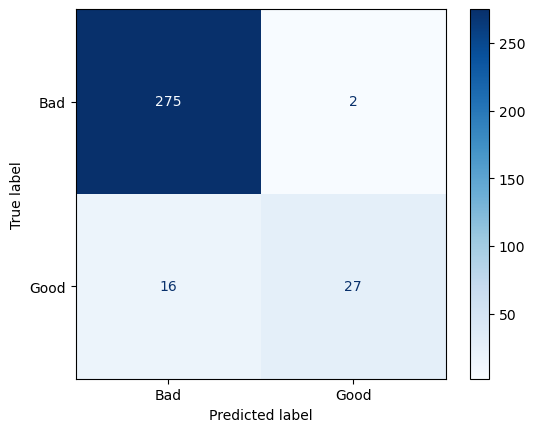

In [51]:
# Visualizing the performance using ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred,
    display_labels=["Bad", "Good"],
    cmap=plt.cm.Blues
)

plt.show()

### Visualizing the Random Forest Classsifier Tree

In [52]:
# Extract a single tree from the Random Forest Classifier Model
single_tree = forest_model.estimators_[0]

In [53]:
feature_names = X.columns

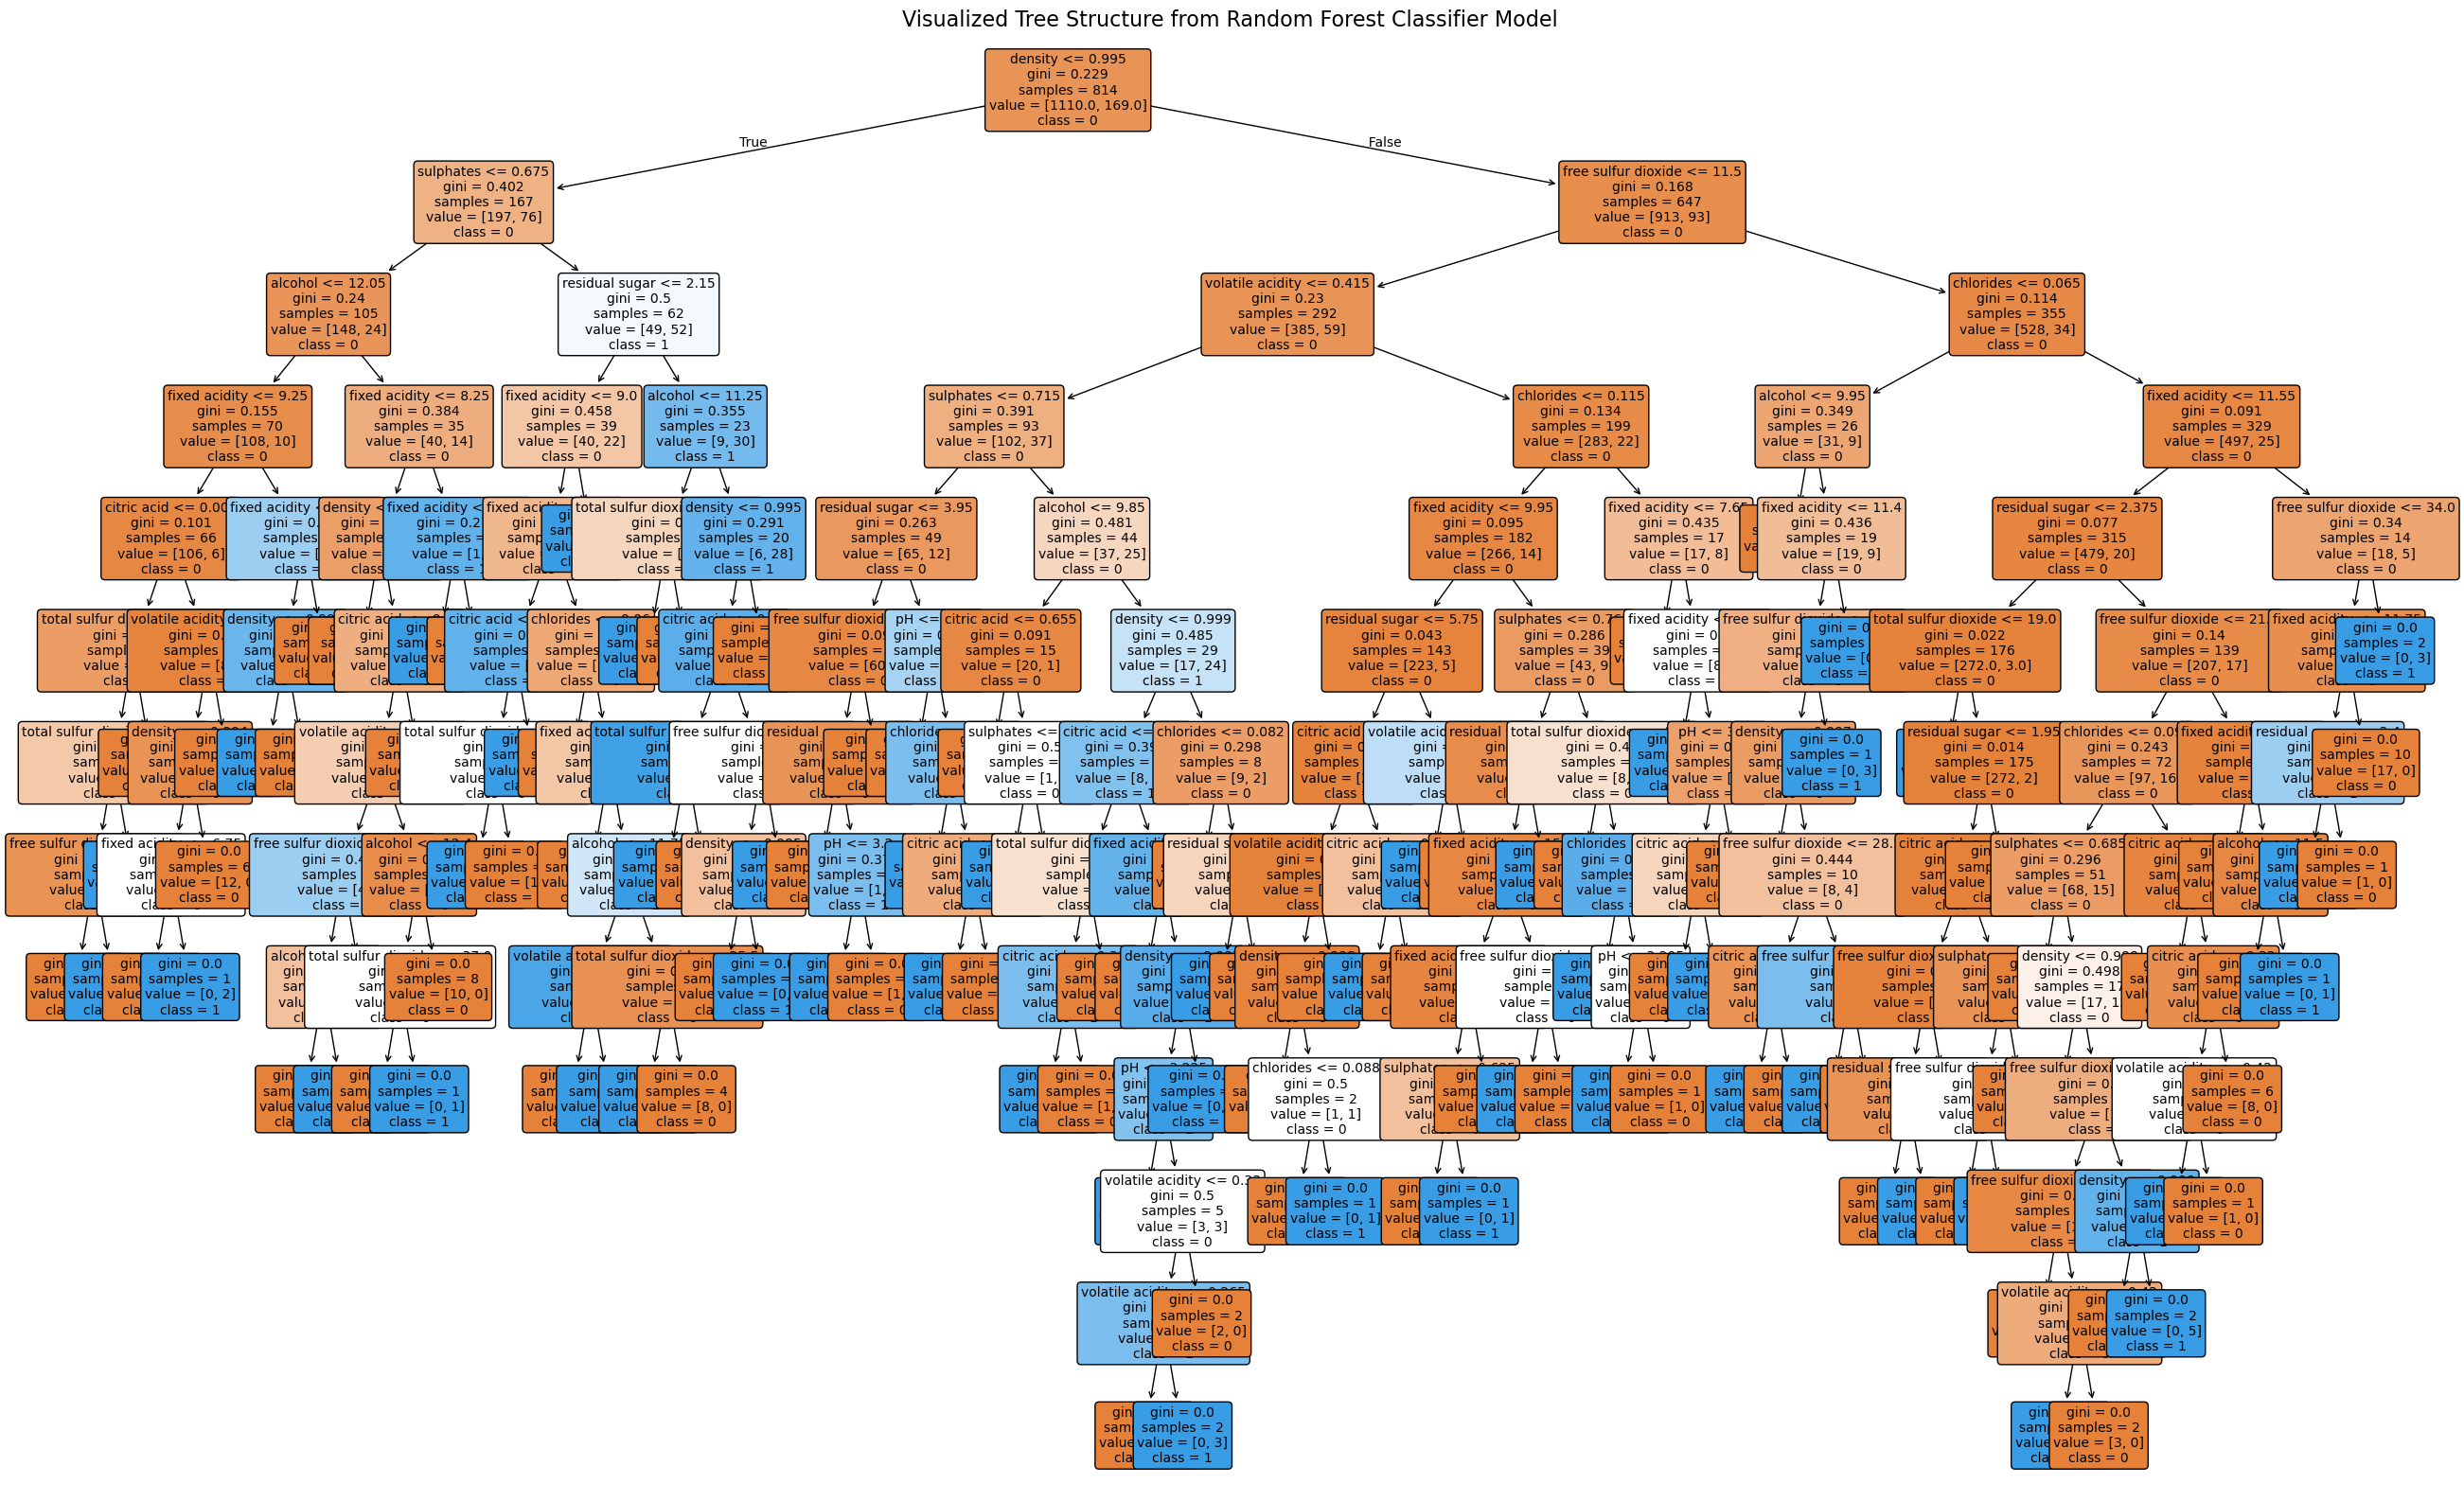

In [57]:
# Plot the extracted decsion tree structure
plt.figure(figsize = (32, 20))


plot_tree(
    single_tree,
    feature_names = feature_names,
    class_names = [str (c) for c in forest_model.classes_],
    filled = True,
    rounded = True,
    fontsize = 10
)

plt.title("Visualized Tree Structure from Random Forest Classifier Model", fontsize = 16)
plt.show()